In [22]:
print("NexoTech Solutions")

NexoTech Solutions


# SAA_LAB01 - Árbol de Decisión: Predicción de abandono de clientes

**Empresa:** NexoTech Solutions

**Objetivo:** utilizar un árbol de decisión para predecir qué clientes pueden abandonar la compañía (`churn`).


## 1. Contexto

NexoTech Solutions es una empresa que ofrece servicios de telecomunicaciones.

La empresa quiere anticiparse al abandono de sus clientes.

Para ello dispone de información sobre:

- la permanencia del cliente;
- el número de llamadas realizadas al soporte técnico;
- la cuota mensual.

El objetivo es construir un modelo de Machine Learning capaz de predecir si un cliente abandonará la compañía.

Para ello utilizaremos un **Árbol de Decisión**.

El flujo de trabajo será:

**Datos → Exploración → Preparación → Entrenamiento → Predicción → Evaluación → Interpretación**


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")

## 2. Creación del conjunto de datos

Vamos a generar un conjunto de datos sintético que representa a clientes de NexoTech Solutions.

Las variables serán:

- `permanencia_meses`: meses que lleva el cliente en la compañía.
- `soporte_tecnico_calls`: número de llamadas al soporte técnico.
- `cuota_mensual`: cuota mensual del cliente.
- `churn`: indica si el cliente ha abandonado la compañía.

En `churn`:

- `0` → el cliente no abandona.
- `1` → el cliente abandona.

In [105]:
np.random.seed(42)

n_samples = 200

data = pd.DataFrame({
    "permanencia_meses": np.random.randint(1, 48, n_samples),
    "soporte_tecnico_calls": np.random.randint(0, 10, n_samples),
    "cuota_mensual": np.random.uniform(30, 120, n_samples)
})

data["churn"] = (
    (data["soporte_tecnico_calls"] > 4) |
    (data["permanencia_meses"] < 6)
).astype(int)

data.head()

,permanencia_meses,soporte_tecnico_calls,cuota_mensual,churn
0,39,6,54.438862,1
1,29,1,116.872665,0
2,15,2,71.153865,0
3,43,0,105.782077,0
4,8,4,47.494203,0


## 3. Exploración de los datos

Antes de entrenar un modelo debemos conocer los datos con los que vamos a trabajar.

In [106]:
data.head()

,permanencia_meses,soporte_tecnico_calls,cuota_mensual,churn
0,39,6,54.438862,1
1,29,1,116.872665,0
2,15,2,71.153865,0
3,43,0,105.782077,0
4,8,4,47.494203,0


In [107]:
data.shape

(200, 4)

In [108]:
data.columns

Index(['permanencia_meses', 'soporte_tecnico_calls', 'cuota_mensual', 'churn'], dtype='str')

In [109]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   permanencia_meses      200 non-null    int32  
 1   soporte_tecnico_calls  200 non-null    int32  
 2   cuota_mensual          200 non-null    float64
 3   churn                  200 non-null    int64  
dtypes: float64(1), int32(2), int64(1)
memory usage: 4.8 KB


In [110]:
data.describe()

,permanencia_meses,soporte_tecnico_calls,cuota_mensual,churn
count,200.000000,200.000000,200.000000,200.000000
mean,24.570000,4.060000,75.662568,0.525000
std,13.715527,2.901464,26.024503,0.500628
min,1.000000,0.000000,31.377409,0.000000
25%,13.000000,2.000000,52.558456,0.000000
50%,25.000000,4.000000,74.892048,1.000000
75%,37.000000,7.000000,96.402245,1.000000
max,47.000000,9.000000,119.633812,1.000000


### Análisis inicial

1. ¿Cuántos clientes tiene el conjunto de datos?
2. ¿Cuál es la permanencia mínima y máxima?
3. ¿Cuántas llamadas al soporte técnico puede tener un cliente?
4. ¿Cuál es aproximadamente la cuota mensual media?
5. ¿La variable `churn` utiliza valores 0 y 1?

## 4. Variables predictoras y variable objetivo

Para entrenar el modelo debemos separar:

- **X** → variables que utilizaremos para realizar las predicciones.
- **y** → variable que queremos predecir.

In [111]:
X = data[
    [
        "permanencia_meses",
        "soporte_tecnico_calls",
        "cuota_mensual"
    ]
]

y = data["churn"]

In [112]:
X.head()

,permanencia_meses,soporte_tecnico_calls,cuota_mensual
0,39,6,54.438862
1,29,1,116.872665
2,15,2,71.153865
3,43,0,105.782077
4,8,4,47.494203


In [113]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: churn, dtype: int64

**¿Cuál es la variable objetivo del modelo?**

## 5. División de los datos

No debemos entrenar y evaluar el modelo utilizando exactamente los mismos datos.

Por ello dividiremos el conjunto en:

- 80 % → entrenamiento.
- 20 % → prueba.

Utilizaremos `random_state=42` para poder reproducir los resultados.


In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [115]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (160, 3)
Datos de prueba: (40, 3)


## 6. Creación del modelo

Utilizaremos un algoritmo de clasificación denominado Árbol de Decisión.

Limitaremos la profundidad del árbol a 3 niveles para evitar que el modelo sea excesivamente complejo.

In [116]:
clf_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

## 7. Entrenamiento

Ahora entrenaremos el árbol utilizando los datos de entrenamiento.

In [117]:
clf_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

## 8. Predicciones

Una vez entrenado el modelo, utilizaremos los datos de prueba para comprobar qué predice.

In [118]:
y_pred = clf_tree.predict(X_test)

In [119]:
print(y_pred[:10])

[0 1 0 0 1 0 1 1 0 0]


In [120]:
print(y_test.values[:10])

[0 1 0 0 1 0 1 1 0 0]


## 9. Evaluación del modelo

La primera métrica que utilizaremos será la Accuracy.

La Accuracy indica qué porcentaje de las predicciones realizadas por el modelo son correctas.

In [121]:
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy en Test Set: {acc * 100:.2f}%")

Accuracy en Test Set: 100.00%


## 10. Matriz de confusión

La matriz de confusión permite analizar con mayor detalle los aciertos y errores del modelo.

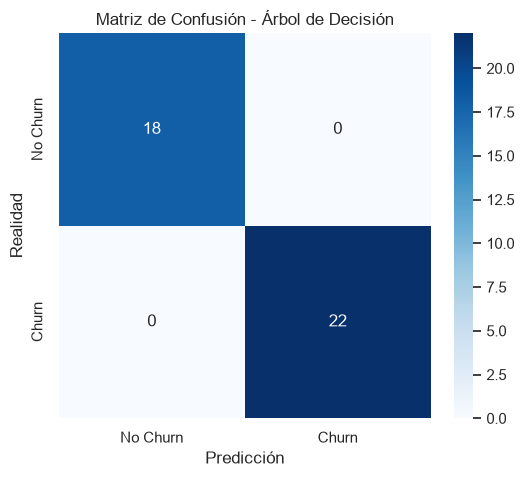

In [122]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Realidad")

plt.show()

11. Visualización del Árbol de Decisión

Una de las ventajas de los árboles de decisión es que podemos visualizar las reglas utilizadas para realizar las predicciones.

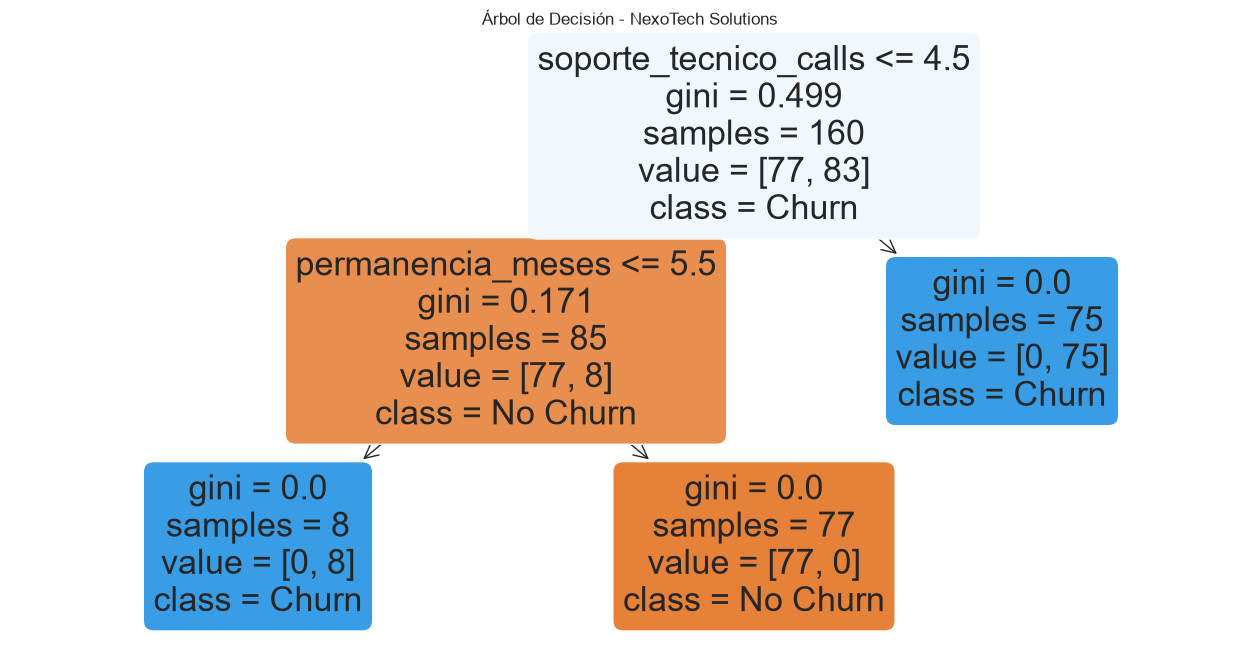

In [123]:
plt.figure(figsize=(16, 8))

plot_tree(
    clf_tree,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True
)

plt.title("Árbol de Decisión - NexoTech Solutions")

plt.show()


## 12. Interpretación del modelo

Analiza el árbol obtenido y responde:

1. ¿Cuál es la primera variable que utiliza el árbol para tomar una decisión?

2. ¿Qué condición aparece en la raíz del árbol?

3. ¿Qué ocurre cuando un cliente tiene muchas llamadas al soporte técnico?

4. ¿Qué ocurre con los clientes que llevan pocos meses en la compañía?

5. ¿Qué variable parece tener mayor importancia en las primeras decisiones del árbol?

6. Escribe dos reglas de decisión que puedas obtener del árbol.


## 13. Interpretación empresarial

NexoTech Solutions no necesita únicamente conocer la Accuracy del modelo.

La empresa quiere utilizar las predicciones para tomar decisiones.

### A. Soporte técnico

¿Qué relación observas entre el número de llamadas al soporte técnico y el abandono?

### B. Permanencia

¿Qué relación observas entre la permanencia del cliente y el abandono?

### C. Acción empresarial

Imagina que NexoTech recibe una predicción indicando que un cliente tiene riesgo de abandono.

¿Qué acción podría realizar la empresa?

Propón al menos dos acciones.